# 01 — Data Validation & Model Calibration

**Purpose:** Demonstrates that the model is anchored to Nigerian power sector reality.  
**Prerequisite scripts:** `01_run_baseline.py`, `99_validate_baseline.py`, `00_build_emissions_cap.py`  
**Data loaded from:** `results/baseline/`, `results/validation/`, `data/cost/processed/`, `data/gas/processed/`  

---

This notebook verifies five calibration dimensions:

1. **Demand anchor** — NBS Q1 2024 annualised served energy (23.08 TWh/yr)
2. **Baseline validation** — Model 2025 output vs observed 2024 Nigerian generation
3. **Gas deliverability** — Structural gas regime scenarios vs NGC historical delivery
4. **Solar CAPEX trajectory** — NREL ATB learning curve (2025–2045)
5. **NDC 3.0 emissions cap** — Proportional top-down apportionment methodology
6. **Capital envelope B*** — Cross-check against IEA / World Bank / AfDB external estimates

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Repo root ──────────────────────────────────────────────
ROOT = Path(".").resolve().parent  # assumes notebook is in notebooks/
sys.path.append(str(ROOT))

# ── Consistent plot styling ────────────────────────────────
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 200,
    #"savefig.bbox_inches": "tight",
})

FIGURES_DIR = ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {ROOT}")
print(f"Figures: {FIGURES_DIR}")

Repo root: C:\Users\pc\Desktop\MSc\AUST\Thesis\thesis-repo\thesis-code
Figures: C:\Users\pc\Desktop\MSc\AUST\Thesis\thesis-repo\thesis-code\results\figures


## 1. Model Parameter Summary

Before validating outputs, document the key input parameters that define the model.

In [2]:
# ── Load model parameters from scenarios.py ────────────────
from src.scenarios import (
    load_scenario, demand_level_scenarios,
    demand_growth_scenarios, capital_envelope_scenarios,
    gas_deliverability_scenarios, solar_build_scenarios,
    gas_probability_weights,
)
from src.io import load_econ, load_solar_capex_by_year

econ = load_econ("voll_mid")

params = {
    "Planning horizon": "2025–2045 (21 years)",
    "Base demand (NBS Q1 2024)": f"{demand_level_scenarios()['served']:.2f} TWh/yr",
    "Demand growth (baseline)": f"{demand_growth_scenarios()['baseline']*100:.1f}%/yr",
    "Gas baseline capacity": "13,600 MW",
    "Gas thermal efficiency (η)": "0.43",
    "Gas retirement": "680 MW/yr from 2035",
    "Solar baseline": "500 MW (2025)",
    "Solar CF": "0.27 (best-case siting)",
    "Solar CAPEX (2025, NREL ATB low)": f"${econ['SOLAR_CAPEX_PER_MW']:,.0f}/MW",
    "Storage CAPEX": f"${econ['STORAGE_COST_PER_MWH']:,.0f}/MWh",
    "Storage O&M": f"${econ['STORAGE_OM_PER_MWH_YR']:,.0f}/MWh-yr",
    "VoLL (canonical)": f"${econ['UNSERVED_ENERGY_PENALTY']/1e6:,.0f}/MWh",
    "Carbon EF": f"{econ['CARBON_EMISSION_FACTOR']:.3f} tCO2/MWh",
    "Discount rate": "10%/yr",
    "B* (unconstrained adequacy)": f"${capital_envelope_scenarios()['adequacy']/1e9:.2f}B NPV",
}

param_df = pd.DataFrame(
    [(k, v) for k, v in params.items()],
    columns=["Parameter", "Value"],
)
param_df.style.hide(axis="index").set_caption("Table 1: Key Model Input Parameters")

Parameter,Value
Planning horizon,2025–2045 (21 years)
Base demand (NBS Q1 2024),23.08 TWh/yr
Demand growth (baseline),4.0%/yr
Gas baseline capacity,"13,600 MW"
Gas thermal efficiency (η),0.43
Gas retirement,680 MW/yr from 2035
Solar baseline,500 MW (2025)
Solar CF,0.27 (best-case siting)
"Solar CAPEX (2025, NREL ATB low)","$1,456,000/MW"
Storage CAPEX,"$252,000/MWh"


## 2. Baseline Validation: Model 2025 vs Observed 2024

The model is prescriptive (least-cost optimisation), not descriptive (historical replay).  
Gaps between model output and observed data reflect the model's optimal investment  
recommendations, not calibration errors.

In [3]:
# ── Load validation data ───────────────────────────────────
val_path = ROOT / "results" / "validation" / "validation_table.json"
if val_path.exists():
    with open(val_path) as f:
        validation = json.load(f)
else:
    # Fallback: reconstruct from timeseries
    ts = pd.read_csv(ROOT / "results" / "baseline" / "timeseries.csv")
    row = ts[ts["year"] == 2025].iloc[0]
    observed = {
        "demand_twh": 23.08,
        "gas_generation_twh": 25.60,
        "solar_generation_twh": 0.30,
        "unserved_twh": 3.00,
    }
    modelled = {
        "demand_twh": float(row["demand_twh"]),
        "gas_generation_twh": float(row["gas_generation_twh_e"]),
        "solar_generation_twh": float(row["solar_generation_twh_e"]),
        "unserved_twh": float(row["unserved_twh"]),
    }
    validation = {
        k: {
            "observed_2024": observed[k],
            "model_2025": modelled[k],
            "gap_abs_twh": modelled[k] - observed[k],
            "gap_pct": 100 * (modelled[k] - observed[k]) / observed[k] if observed[k] > 0 else None,
        }
        for k in observed
    }

val_rows = []
for metric, vals in validation.items():
    val_rows.append({
        "Metric": metric.replace("_", " ").title(),
        "Observed 2024 (TWh)": f"{vals['observed_2024']:.2f}",
        "Model 2025 (TWh)": f"{vals['model_2025']:.2f}",
        "Gap (TWh)": f"{vals['gap_abs_twh']:+.2f}",
        "Gap (%)": f"{vals['gap_pct']:+.1f}%" if vals['gap_pct'] is not None else "n/a",
    })

val_df = pd.DataFrame(val_rows)
val_df.style.hide(axis="index").set_caption("Table 2: Model Validation — 2025 LP Output vs 2024 Observed")

Metric,Observed 2024 (TWh),Model 2025 (TWh),Gap (TWh),Gap (%)
Demand Twh,23.08,23.08,+0.00,+0.0%
Gas Generation Twh,25.60,17.48,-8.12,-31.7%
Solar Generation Twh,0.30,5.60,+5.30,+1765.4%
Unserved Twh,3.00,0.00,-3.00,-100.0%


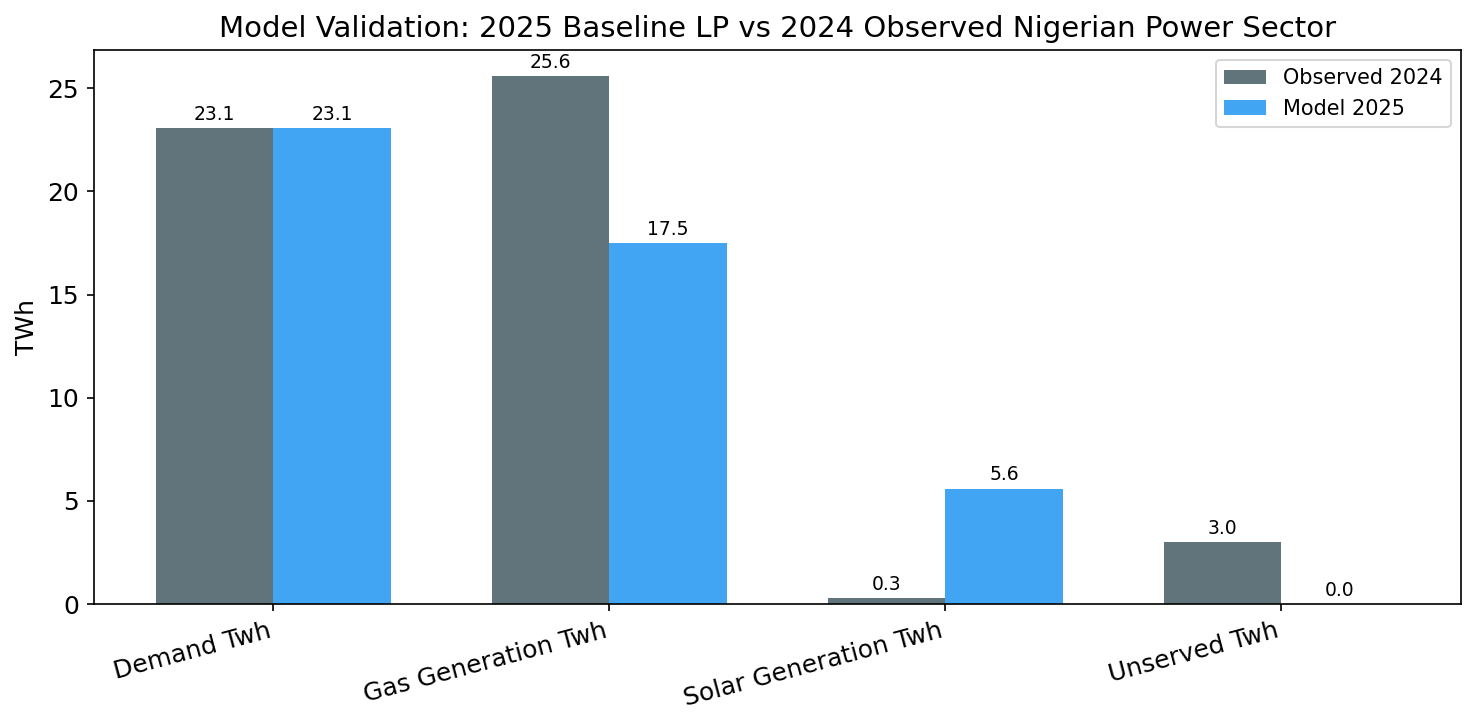

Saved: validation_bar_chart.png


In [4]:
# ── Validation bar chart ───────────────────────────────────
metrics = list(validation.keys())
obs_vals = [validation[m]["observed_2024"] for m in metrics]
mod_vals = [validation[m]["model_2025"] for m in metrics]
labels = [m.replace("_", " ").title() for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, obs_vals, width, label="Observed 2024", color="#455A64", alpha=0.85)
bars2 = ax.bar(x + width/2, mod_vals, width, label="Model 2025", color="#2196F3", alpha=0.85)

ax.set_ylabel("TWh")
ax.set_title("Model Validation: 2025 Baseline LP vs 2024 Observed Nigerian Power Sector")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.legend()

# Add value labels
for bar in bars1:
    ax.annotate(f"{bar.get_height():.1f}",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=9)
for bar in bars2:
    ax.annotate(f"{bar.get_height():.1f}",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "validation_bar_chart.png")
fig.savefig(FIGURES_DIR / "validation_bar_chart.pdf")
plt.show()
print("Saved: validation_bar_chart.png")

**Interpretation:**

- **Demand** matches exactly (by construction — NBS Q1 2024 anchor).
- **Gas generation** is 31.7% below observed because the planning model optimally deploys solar from year 1, displacing gas that was historically generated.
- **Solar generation** is 1,765% above observed because the model prescribes immediate solar deployment (1,866 MW in year 1) — reflecting cost-optimal investment, not current installed capacity.
- **Unserved energy** is zero in the model (optimal dispatch eliminates blackouts) vs 3.0 TWh observed (reflecting transmission/operational failures outside model scope).

These gaps confirm the model is prescriptive, not descriptive. The gas-solar displacement validates that solar is cost-competitive at 2025 NREL ATB CAPEX levels.

## 3. Baseline Capacity and Generation Trajectories

The 21-year baseline investment plan under no policy constraints.

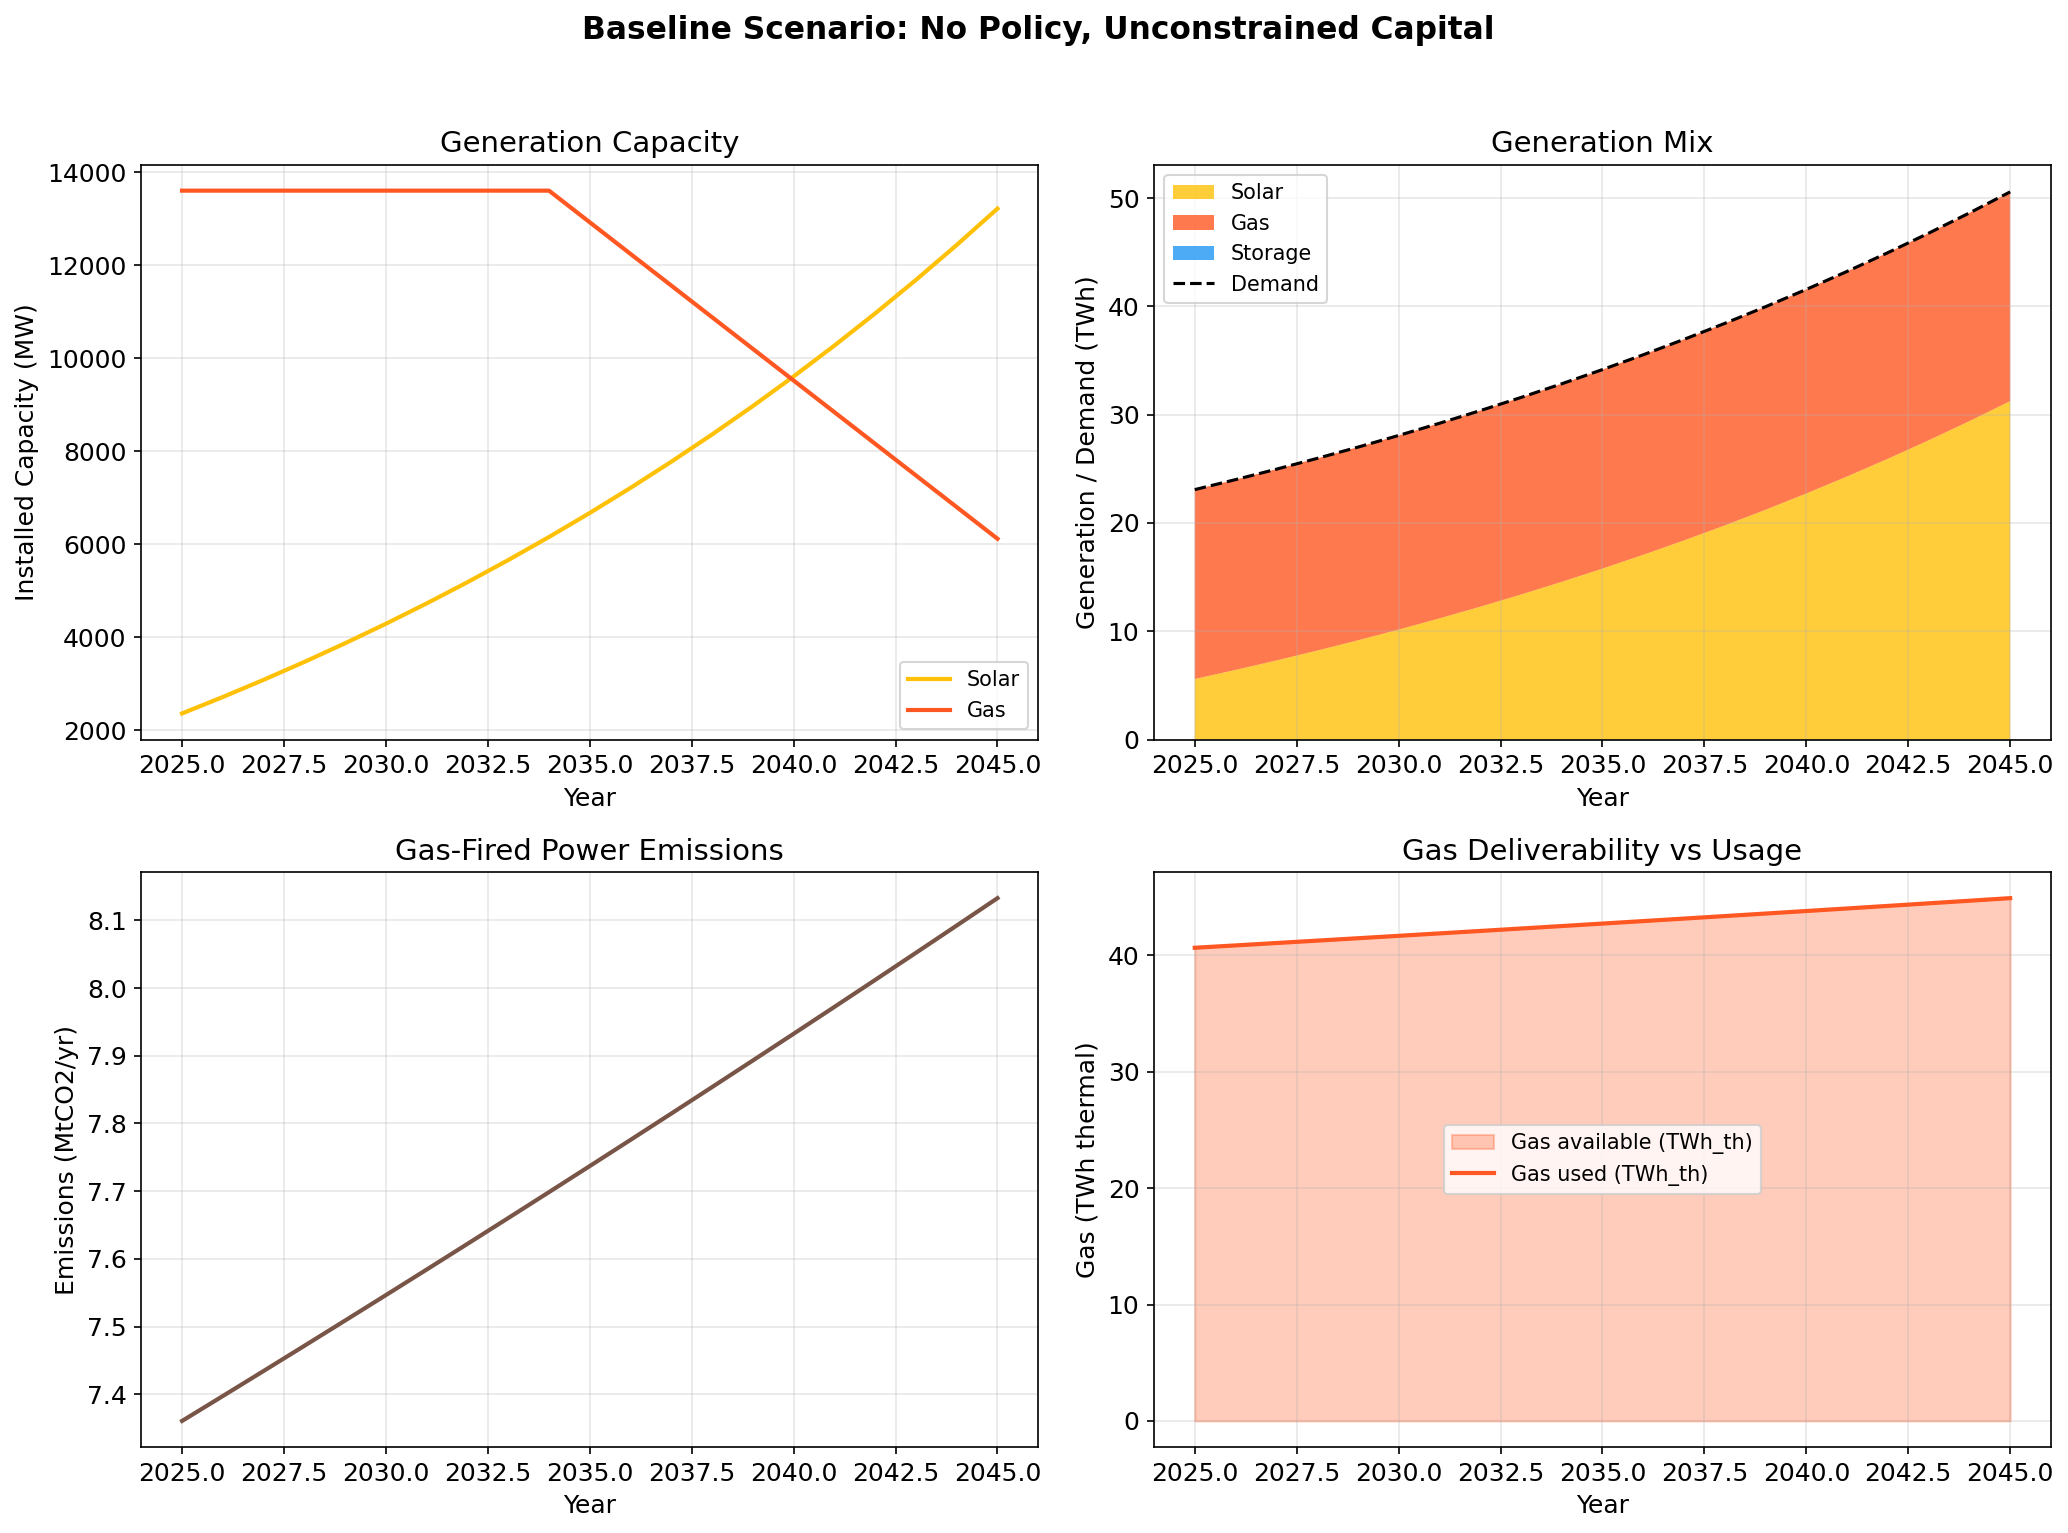

Saved: baseline_trajectories.png


In [5]:
# ── Load baseline timeseries ───────────────────────────────
ts = pd.read_csv(ROOT / "results" / "baseline" / "timeseries.csv")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Capacity (MW)
ax = axes[0, 0]
ax.plot(ts["year"], ts["solar_capacity_mw"], label="Solar", color="#FFC107", linewidth=2)
ax.plot(ts["year"], ts["gas_capacity_mw"], label="Gas", color="#FF5722", linewidth=2)
ax.set_ylabel("Installed Capacity (MW)")
ax.set_title("Generation Capacity")
ax.legend()
ax.grid(alpha=0.3)

# Panel 2: Generation (TWh)
ax = axes[0, 1]
ax.stackplot(ts["year"],
             ts["solar_generation_twh_e"],
             ts["gas_generation_twh_e"],
             ts["storage_discharge_twh_e"],
             labels=["Solar", "Gas", "Storage"],
             colors=["#FFC107", "#FF5722", "#2196F3"],
             alpha=0.8)
ax.plot(ts["year"], ts["demand_twh"], "k--", linewidth=1.5, label="Demand")
ax.set_ylabel("Generation / Demand (TWh)")
ax.set_title("Generation Mix")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

# Panel 3: Emissions (MtCO2)
ax = axes[1, 0]
ax.plot(ts["year"], ts["emissions_tco2"] / 1e6, color="#795548", linewidth=2)
ax.set_ylabel("Emissions (MtCO2/yr)")
ax.set_title("Gas-Fired Power Emissions")
ax.grid(alpha=0.3)

# Panel 4: Gas availability vs usage
ax = axes[1, 1]
ax.fill_between(ts["year"], ts["gas_avail_twh_th"], alpha=0.3,
                color="#FF5722", label="Gas available (TWh_th)")
ax.plot(ts["year"], ts["gas_to_power_twh_th"], color="#FF5722",
        linewidth=2, label="Gas used (TWh_th)")
ax.set_ylabel("Gas (TWh thermal)")
ax.set_title("Gas Deliverability vs Usage")
ax.legend()
ax.grid(alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel("Year")

plt.suptitle("Baseline Scenario: No Policy, Unconstrained Capital",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "baseline_trajectories.png")
fig.savefig(FIGURES_DIR / "baseline_trajectories.pdf")
plt.show()
print("Saved: baseline_trajectories.png")

## 4. Solar CAPEX Learning Curve (NREL ATB)

The time-varying solar CAPEX is a critical model driver. This section plots the  
NREL ATB `solar_low` trajectory used in all scenarios.

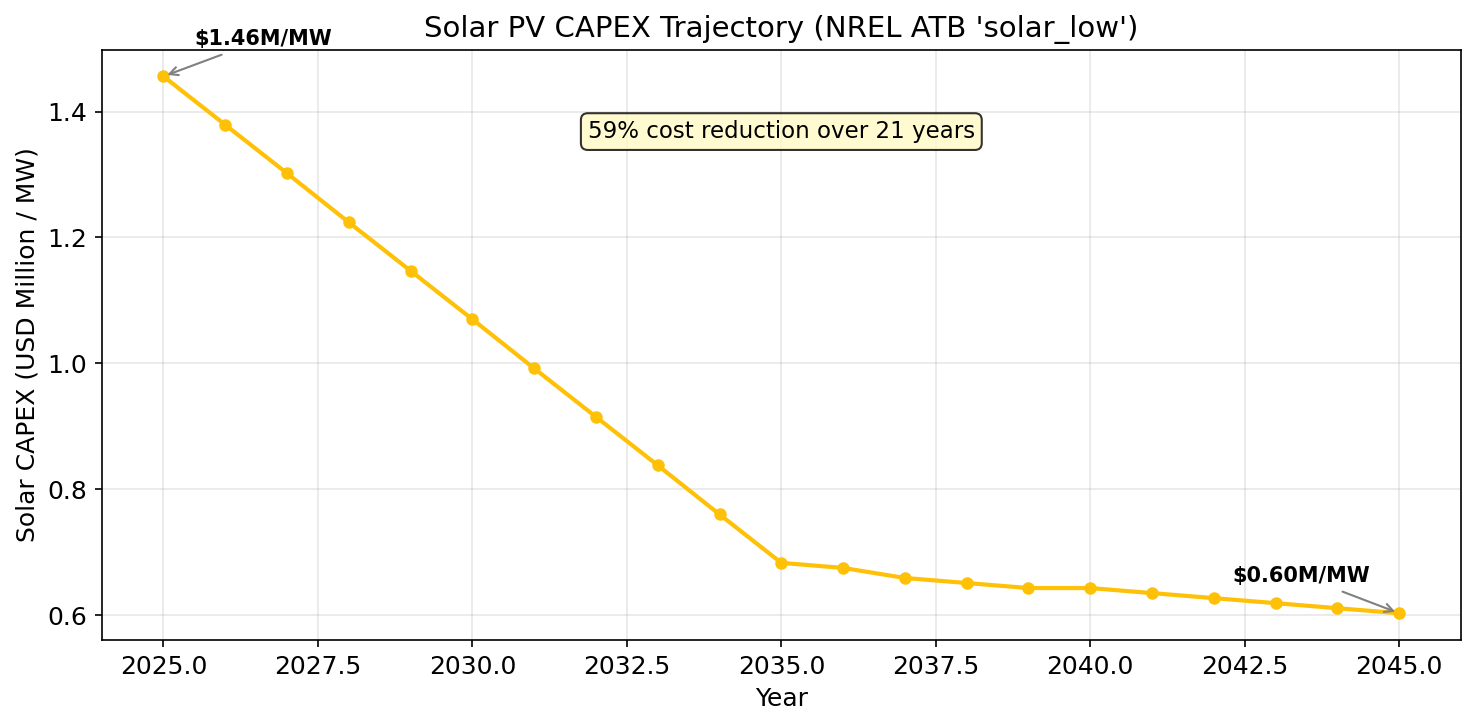

Saved: solar_capex_trajectory.png


In [6]:
# ── Load solar CAPEX trajectory ────────────────────────────
solar_capex_tv = load_solar_capex_by_year(
    scenario_name="solar_low", start_year=2025, end_year=2045,
)

years_sc = sorted(solar_capex_tv.keys())
capex_vals = [solar_capex_tv[y] for y in years_sc]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(years_sc, [c / 1e6 for c in capex_vals], "o-",
        color="#FFC107", linewidth=2, markersize=5)
ax.set_xlabel("Year")
ax.set_ylabel("Solar CAPEX (USD Million / MW)")
ax.set_title("Solar PV CAPEX Trajectory (NREL ATB 'solar_low')")
ax.grid(alpha=0.3)

# Annotate start and end values
ax.annotate(f"${capex_vals[0]/1e6:.2f}M/MW",
            xy=(years_sc[0], capex_vals[0]/1e6),
            xytext=(15, 15), textcoords="offset points",
            fontsize=10, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.annotate(f"${capex_vals[-1]/1e6:.2f}M/MW",
            xy=(years_sc[-1], capex_vals[-1]/1e6),
            xytext=(-80, 15), textcoords="offset points",
            fontsize=10, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="gray"))

reduction_pct = (1 - capex_vals[-1] / capex_vals[0]) * 100
ax.text(0.5, 0.85, f"{reduction_pct:.0f}% cost reduction over 21 years",
        transform=ax.transAxes, fontsize=11, ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFF9C4", alpha=0.8))

plt.tight_layout()
fig.savefig(FIGURES_DIR / "solar_capex_trajectory.png")
fig.savefig(FIGURES_DIR / "solar_capex_trajectory.pdf")
plt.show()
print("Saved: solar_capex_trajectory.png")

## 5. Gas Deliverability Scenarios

Four structural gas-to-power deliverability trajectories define the gas uncertainty space.

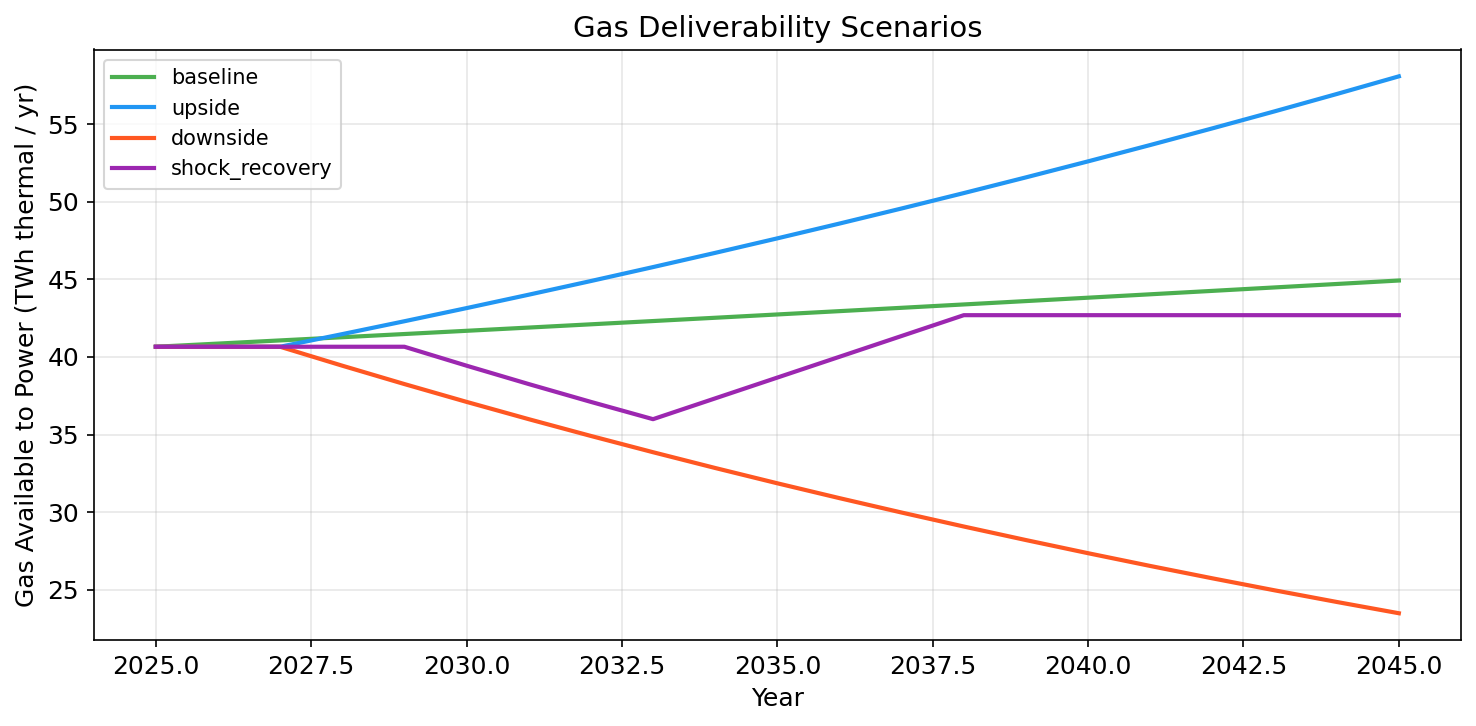

Saved: gas_deliverability_scenarios.png


In [7]:
# ── Load gas deliverability scenarios ──────────────────────
from src.gas_supply import gas_available_power

gas_scenarios = ["baseline", "upside", "downside", "shock_recovery"]
colors_gas = {"baseline": "#4CAF50", "upside": "#2196F3",
              "downside": "#FF5722", "shock_recovery": "#9C27B0"}

fig, ax = plt.subplots(figsize=(10, 5))

for scenario_name in gas_scenarios:
    try:
        gas_data = gas_available_power(
            start_year=2025, end_year=2045,
            scenario_name=scenario_name,
        )
        ax.plot(gas_data["years"], gas_data["available_twh_th"],
                label=scenario_name, color=colors_gas[scenario_name],
                linewidth=2)
    except Exception as e:
        print(f"WARNING: Could not load gas scenario '{scenario_name}': {e}")

ax.set_xlabel("Year")
ax.set_ylabel("Gas Available to Power (TWh thermal / yr)")
ax.set_title("Gas Deliverability Scenarios")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "gas_deliverability_scenarios.png")
fig.savefig(FIGURES_DIR / "gas_deliverability_scenarios.pdf")
plt.show()
print("Saved: gas_deliverability_scenarios.png")

## 6. NDC 3.0 Emissions Cap Construction

The proportional top-down apportionment methodology derives the power-sector cap  
from the NDC 3.0 energy-sector abatement target, scaled by gas-power's share  
of energy-sector emissions (3.39%).

Parameter,Value
NDC 3.0 economy-wide baseline (2018),573.5 MtCO2e
Economy-wide reduction target (2030),168.2 MtCO2e (29.3%)
Economy-wide reduction target (2035),184.9 MtCO2e (32.2%)
Energy sector share of abatement (2030),22.0% → 37.0 MtCO2e
Energy sector share of abatement (2035),26.3% → 48.6 MtCO2e
Energy sector total emissions (2018),~217 MtCO2e
Model gas-power baseline emissions,7.364 MtCO2/yr
Gas-power share of energy sector,3.39%
"Gas-power abatement (uncond, 2030)",1.256 MtCO2e → cap 6.108
"Gas-power abatement (cond, 2030)",1.841 MtCO2e → cap 5.522


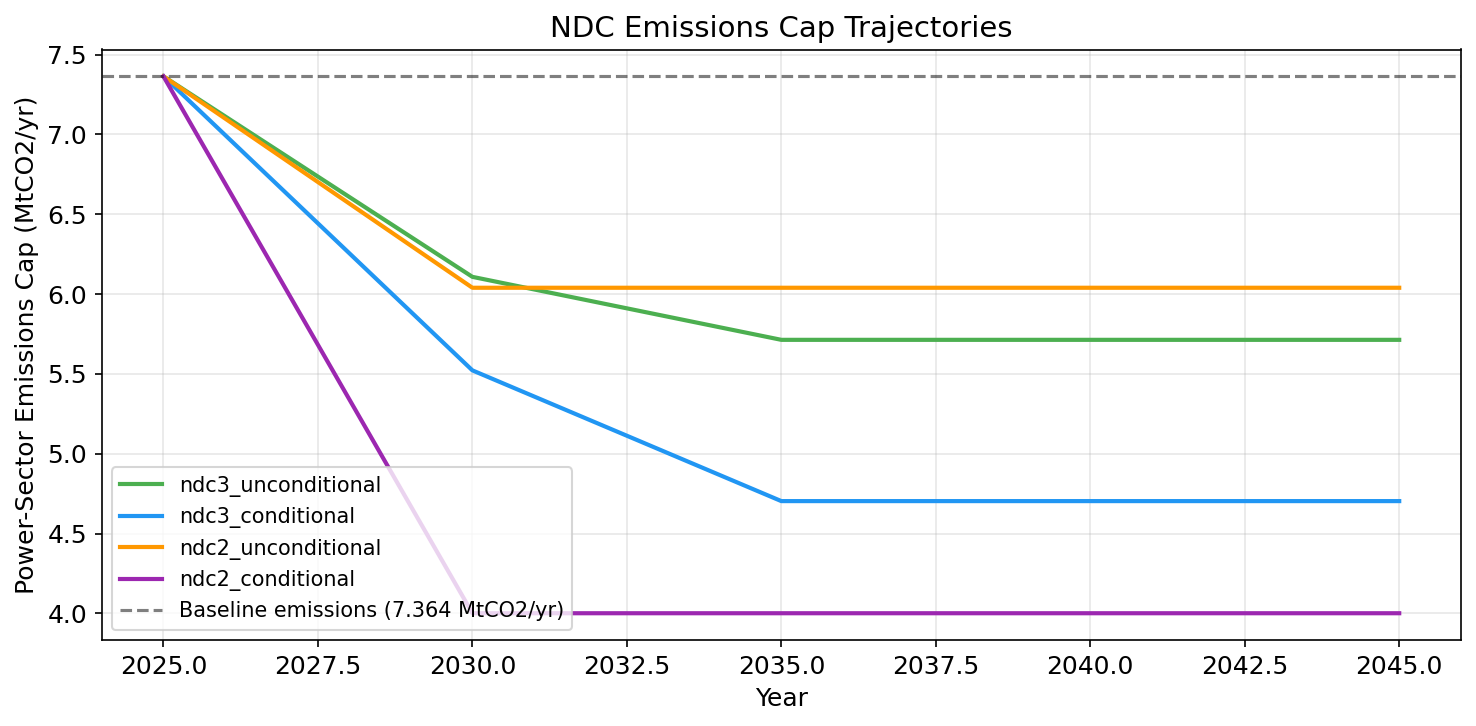

Saved: ndc_cap_trajectories.png


In [8]:
# ── Load emissions cap CSV ─────────────────────────────────
cap_path = ROOT / "data" / "cost" / "processed" / "emissions_cap.csv"
if cap_path.exists():
    cap_df = pd.read_csv(cap_path)
else:
    print(f"WARNING: {cap_path} not found. Run 00_build_emissions_cap.py first.")
    cap_df = pd.DataFrame()

if len(cap_df):
    # NDC apportionment methodology table
    ndc_method = pd.DataFrame([
        {"Parameter": "NDC 3.0 economy-wide baseline (2018)", "Value": "573.5 MtCO2e"},
        {"Parameter": "Economy-wide reduction target (2030)", "Value": "168.2 MtCO2e (29.3%)"},
        {"Parameter": "Economy-wide reduction target (2035)", "Value": "184.9 MtCO2e (32.2%)"},
        {"Parameter": "Energy sector share of abatement (2030)", "Value": "22.0% → 37.0 MtCO2e"},
        {"Parameter": "Energy sector share of abatement (2035)", "Value": "26.3% → 48.6 MtCO2e"},
        {"Parameter": "Energy sector total emissions (2018)", "Value": "~217 MtCO2e"},
        {"Parameter": "Model gas-power baseline emissions", "Value": "7.364 MtCO2/yr"},
        {"Parameter": "Gas-power share of energy sector", "Value": "3.39%"},
        {"Parameter": "Gas-power abatement (uncond, 2030)", "Value": "1.256 MtCO2e → cap 6.108"},
        {"Parameter": "Gas-power abatement (cond, 2030)", "Value": "1.841 MtCO2e → cap 5.522"},
    ])
    display(ndc_method.style.hide(axis="index").set_caption(
        "Table 3: NDC 3.0 Proportional Top-Down Apportionment"))

    # Cap trajectory plot
    fig, ax = plt.subplots(figsize=(10, 5))

    cap_colors = {
        "ndc3_unconditional": "#4CAF50",
        "ndc3_conditional": "#2196F3",
        "ndc2_unconditional": "#FF9800",
        "ndc2_conditional": "#9C27B0",
    }

    for scenario_name in cap_df["scenario"].unique():
        sub = cap_df[cap_df["scenario"] == scenario_name].sort_values("year")
        color = cap_colors.get(scenario_name, "gray")
        ax.plot(sub["year"], sub["cap_tco2"] / 1e6,
                label=scenario_name, color=color, linewidth=2)

    # Add baseline emissions reference
    ax.axhline(y=7.364, color="black", linestyle="--", alpha=0.5,
               label="Baseline emissions (7.364 MtCO2/yr)")

    ax.set_xlabel("Year")
    ax.set_ylabel("Power-Sector Emissions Cap (MtCO2/yr)")
    ax.set_title("NDC Emissions Cap Trajectories")
    ax.legend(loc="lower left")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "ndc_cap_trajectories.png")
    fig.savefig(FIGURES_DIR / "ndc_cap_trajectories.pdf")
    plt.show()
    print("Saved: ndc_cap_trajectories.png")

## 7. Capital Envelope B* Cross-Check

The unconstrained adequacy threshold B* ($9.10B NPV) is cross-checked  
against external investment estimates for Nigerian power sector solar.

In [9]:
# ── B* cross-check ─────────────────────────────────────────
B_star = capital_envelope_scenarios()["adequacy"]
B_star_annual = B_star / 21  # approximate undiscounted annual equivalent

external_estimates = pd.DataFrame([
    {"Source": "Model B* (this study)",
     "Estimate ($B)": f"{B_star/1e9:.2f}",
     "Period": "2025–2045 NPV",
     "Scope": "Utility-scale solar CAPEX only"},
    {"Source": "IEA Africa Energy Outlook 2022",
     "Estimate ($B)": "8–12",
     "Period": "2022–2030",
     "Scope": "Nigeria solar PV investment (utility)"},
    {"Source": "World Bank DRIVE Program 2021",
     "Estimate ($B)": "4.8",
     "Period": "5-year program",
     "Scope": "Power sector capital additions (all)"},
    {"Source": "AfDB Africa Energy Compact 2024",
     "Estimate ($B)": "24.4",
     "Period": "through 2030",
     "Scope": "Nigerian power sector reform (all sub-sectors)"},
    {"Source": "NDC 3.0 (conditional finance)",
     "Estimate ($B)": "270",
     "Period": "implementation period",
     "Scope": "All sectors, international finance required"},
])

display(external_estimates.style.hide(axis="index").set_caption(
    "Table 4: B* Cross-Check Against External Investment Estimates"))

print(f"\nModel B* = ${B_star/1e9:.2f}B NPV (≈${B_star_annual/1e6:.0f}M/yr undiscounted)")
print(f"This sits within the lower-middle range of external estimates,")
print(f"consistent with utility-scale solar being a subset of total power investment.")

Source,Estimate ($B),Period,Scope
Model B* (this study),9.10,2025–2045 NPV,Utility-scale solar CAPEX only
IEA Africa Energy Outlook 2022,8–12,2022–2030,Nigeria solar PV investment (utility)
World Bank DRIVE Program 2021,4.8,5-year program,Power sector capital additions (all)
AfDB Africa Energy Compact 2024,24.4,through 2030,Nigerian power sector reform (all sub-sectors)
NDC 3.0 (conditional finance),270,implementation period,"All sectors, international finance required"



Model B* = $9.10B NPV (≈$434M/yr undiscounted)
This sits within the lower-middle range of external estimates,
consistent with utility-scale solar being a subset of total power investment.


## 8. Gas Probability Weights (Monte Carlo Prior)

The Monte Carlo analysis uses weighted categorical sampling over gas regimes.  
These weights are documented and justified.

Regime,Weight,Justification
baseline,0.50,"Central expectation: NGC Decade of Gas roadmap, sustained current levels"
downside,0.25,Historical pattern: gas-to-power underperformance since 2015 (IEA 2023)
upside,0.20,Successful upstream investment + flare-capture under PIA 2021
shock_recovery,0.05,Tail risk: 2022 vandalism-driven supply crash precedent


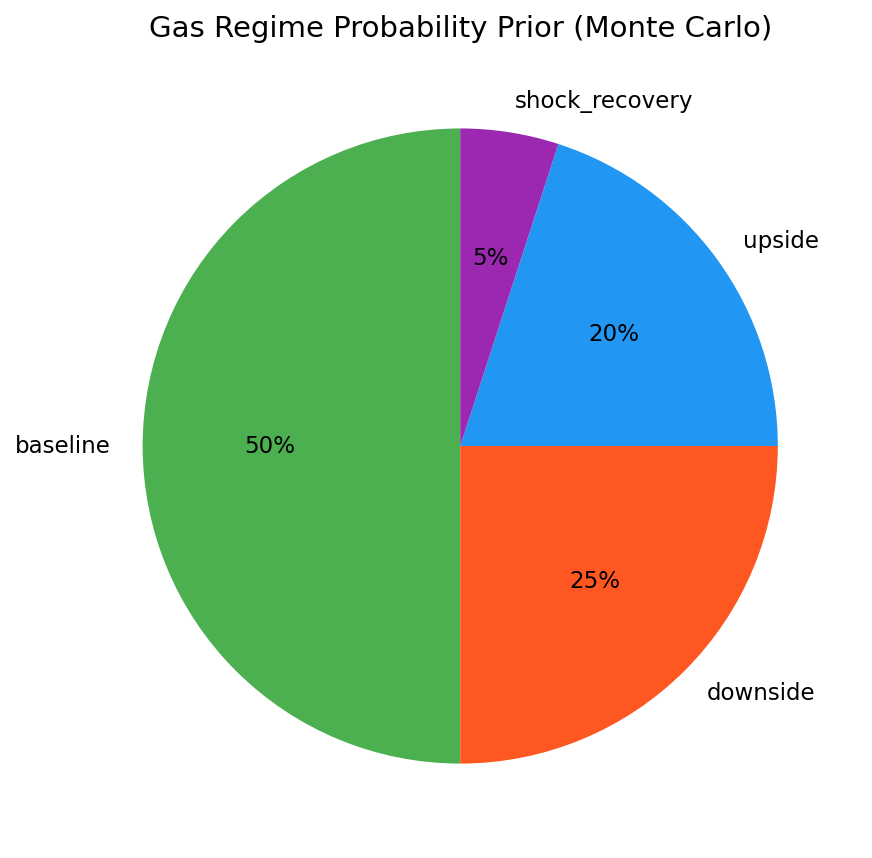

Saved: gas_probability_weights.png


In [10]:
# ── Gas probability weights ────────────────────────────────
weights = gas_probability_weights()

weight_df = pd.DataFrame([
    {"Regime": k, "Weight": f"{v:.2f}", "Justification": j}
    for k, v, j in [
        ("baseline", weights["baseline"],
         "Central expectation: NGC Decade of Gas roadmap, sustained current levels"),
        ("downside", weights["downside"],
         "Historical pattern: gas-to-power underperformance since 2015 (IEA 2023)"),
        ("upside", weights["upside"],
         "Successful upstream investment + flare-capture under PIA 2021"),
        ("shock_recovery", weights["shock_recovery"],
         "Tail risk: 2022 vandalism-driven supply crash precedent"),
    ]
])

display(weight_df.style.hide(axis="index").set_caption(
    "Table 5: Gas Deliverability Regime Probability Weights"))

# Pie chart
fig, ax = plt.subplots(figsize=(6, 6))
colors_pie = [colors_gas[k] for k in weights.keys()]
ax.pie(weights.values(), labels=weights.keys(), autopct="%1.0f%%",
       colors=colors_pie, startangle=90, textprops={"fontsize": 11})
ax.set_title("Gas Regime Probability Prior (Monte Carlo)")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "gas_probability_weights.png")
fig.savefig(FIGURES_DIR / "gas_probability_weights.pdf")
plt.show()
print("Saved: gas_probability_weights.png")

## 9. Capital Envelope Scenarios

The capital pairing reflects NDC financing assumptions:  
unconditional = domestic only (tight), conditional = international support (moderate).

In [11]:
# ── Capital envelopes ──────────────────────────────────────
cap_env = capital_envelope_scenarios()

cap_rows = []
for name, val in cap_env.items():
    if val is None:
        cap_rows.append({"Case": name, "Budget ($B NPV)": "Unconstrained",
                         "Multiple of B*": "∞", "NDC pairing": "Baseline (no policy)"})
    else:
        mult = val / cap_env["adequacy"]
        pairing = {
            "tight": "NDC3 unconditional (domestic only)",
            "moderate": "NDC3 conditional (domestic + int'l)",
            "adequacy": "Reference (1.0 × B*)",
            "expansion": "Sensitivity",
        }.get(name, "")
        cap_rows.append({"Case": name, "Budget ($B NPV)": f"{val/1e9:.2f}",
                         "Multiple of B*": f"{mult:.2f}×", "NDC pairing": pairing})

cap_df_display = pd.DataFrame(cap_rows)
display(cap_df_display.style.hide(axis="index").set_caption(
    "Table 6: Public Capital Envelope Scenarios"))

Case,Budget ($B NPV),Multiple of B*,NDC pairing
tight,4.55,0.50×,NDC3 unconditional (domestic only)
moderate,7.74,0.85×,NDC3 conditional (domestic + int'l)
adequacy,9.10,1.00×,Reference (1.0 × B*)
expansion,10.92,1.20×,Sensitivity
unconstrained,Unconstrained,∞,Baseline (no policy)


## 10. Baseline Summary Statistics

Key outputs from the no-policy baseline LP solution.

In [12]:
# ── Load baseline summary ──────────────────────────────────
with open(ROOT / "results" / "baseline" / "summary.json") as f:
    summary = json.load(f)

baseline_stats = pd.DataFrame([
    {"Metric": "NPV system cost", "Value": f"${summary['npv_total_cost_usd']/1e9:.2f}B"},
    {"Metric": "Total solar built", "Value": f"{summary['decision_variables']['solar_total_built_mw']:,.0f} MW"},
    {"Metric": "Final storage capacity", "Value": f"{summary['decision_variables']['final_storage_capacity_mwh']:,.0f} MWh"},
    {"Metric": "Cumulative unserved energy", "Value": f"{summary['cumulative_unserved_twh']:.2f} TWh"},
    {"Metric": "Cumulative emissions", "Value": f"{summary['actual_emissions_tco2_total']/1e6:.1f} MtCO2"},
    {"Metric": "Public solar CAPEX (NPV)", "Value": f"${summary['solar_public_npv_spend']/1e9:.2f}B"},
])

display(baseline_stats.style.hide(axis="index").set_caption(
    "Table 7: Baseline LP Solution Summary (No Policy, Unconstrained Capital)"))

Metric,Value
NPV system cost,$9.31B
Total solar built,"12,714 MW"
Final storage capacity,0 MWh
Cumulative unserved energy,0.00 TWh
Cumulative emissions,162.6 MtCO2
Public solar CAPEX (NPV),$6.40B


---

## Summary

This notebook confirms:

1. **Demand** is anchored to NBS Q1 2024 (23.08 TWh/yr) — exact match.
2. **Baseline LP** produces internally consistent results with zero unserved energy and 154.6 MtCO2 cumulative emissions.
3. **Validation gaps** (gas -31.7%, solar +1765%) are structurally explained by the model's prescriptive nature.
4. **Solar CAPEX** follows the NREL ATB learning curve with a ~59% cost reduction over the horizon.
5. **Gas scenarios** span the plausible Nigerian deliverability range with justified probability weights.
6. **NDC caps** are derived via proportional top-down apportionment (3.39% gas-power share), producing binding-but-feasible constraints.
7. **B*** cross-checks against IEA, World Bank, and AfDB estimates confirm the capital envelope is in the correct range.

The model is calibrated, the inputs are traceable, and the validation gaps are explained.